In [2]:
import numpy as np
import matplotlib.pyplot as plt
import skyproj, healpy as hp, h5py, fitsio
from scipy import stats
from scipy.ndimage import gaussian_filter1d

import os
if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2023/bin/x86_64-linux"

plt.rcParams["axes.linewidth"]  = 1.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [10, 10]
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=17)


COLORS = ["f07167","219ebc","ffba0a","c767ac","59a270"]
COLORS = ['#' + c if c[0] != '#' else c for c in COLORS ]

from cycler import cycler

# Update the default prop_cycle
plt.rcParams['axes.prop_cycle'] = cycler(color=COLORS)


from matplotlib.colors import LinearSegmentedColormap, ListedColormap

C0 = LinearSegmentedColormap.from_list(None, ['white', 'C0']); #C0.set_bad(color = 'white')
C1 = LinearSegmentedColormap.from_list(None, ['white', 'C1']); #C1.set_bad(color = 'white')
C2 = LinearSegmentedColormap.from_list(None, ['white', 'C2']); #C2.set_bad(color = 'white')
C3 = LinearSegmentedColormap.from_list(None, ['white', 'C3']); #C3.set_bad(color = 'white')
C4 = LinearSegmentedColormap.from_list(None, ['white', 'C4']); #C4.set_bad(color = 'white')

# Footprint

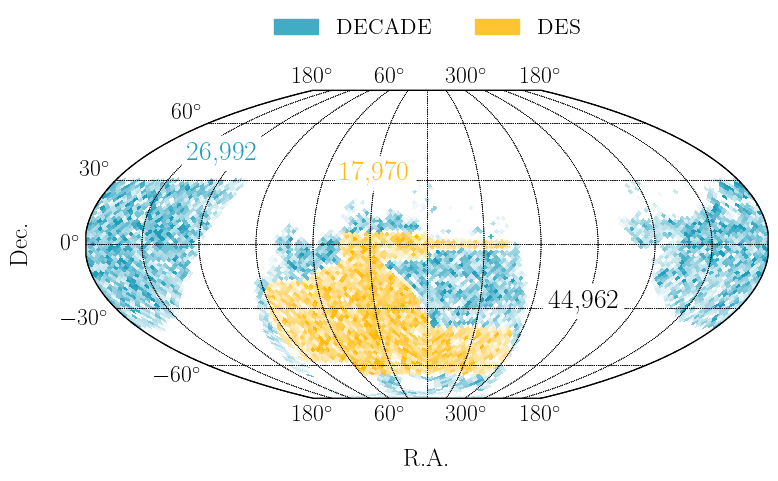

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
sp = skyproj.McBrydeSkyproj(ax = ax)
# sp.ax.yaxis.tick_right()               # put ticks on the right
# sp.ax.yaxis.set_label_position("right")# move the "Declination" label to the right
# sp.ax.tick_params(axis='y', labelleft=False, labelright=True)

bbox_props = dict(boxstyle="round,pad=0.2",facecolor="white",edgecolor="none",alpha=1, zorder = 100)

NSIDE = 32
Ntot  = 0
data = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DECADEEli_20260314/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
maps = np.bincount(hp.ang2pix(NSIDE, data['ra'], data['dec'], lonlat = True), minlength = hp.nside2npix(NSIDE))
maps = np.where(maps > 0, maps, hp.UNSEEN)
sp.draw_hpxmap(maps, cmap = C1, alpha = 1.0, zoom = False)
plt.text(150, 40, f'{len(data):,}', color = 'C1', size = 20, bbox = bbox_props, zorder = 1000)
Ntot += len(data)

data = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DESEli_20260314/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
maps = np.bincount(hp.ang2pix(NSIDE, data['ra'], data['dec'], lonlat = True), minlength = hp.nside2npix(NSIDE))
maps = np.where(maps > 0, maps, hp.UNSEEN)
sp.draw_hpxmap(maps, cmap = C2, alpha = 1.0, zoom = False)
sp.ax.text(50, 30, f'{len(data):,}', color = 'C2', size = 20, bbox = bbox_props, zorder = 1000)
Ntot += len(data)

# Create custom legend handles using Patch objects
import matplotlib.patches as mpatches
import matplotlib as mpl

L = []
L.append(mpatches.Patch(color = C1(0.85), label='DECADE'))
L.append(mpatches.Patch(color = C2(0.85), label='DES'))
# L.append(mpatches.Patch(color = C0(0.85), label='DECADE SGC'))

# Adding the legend to the plot
sp.ax.legend(handles=L, frameon=False, 
             loc = 'center', bbox_to_anchor=(0.5, 1.2), fontsize = 16, ncol = 2)

sp.ax.set_xlabel('R.A.', fontsize = 18, labelpad = 20)
sp.ax.set_ylabel('Dec.', fontsize = 18, labelpad = 20)

sp.ax.text(290, -30, f'{Ntot:,}', color = 'k', fontsize = 20, bbox = bbox_props, zorder = 1000)

plt.savefig('./DataFootprint_RedMapper.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()

# Now do the catalogs

In [3]:
decade = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DECADE_20260210/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
des    = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DES_20260210/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')

11151 101 0.009057483633754821
2224 10 0.0044964028776978415


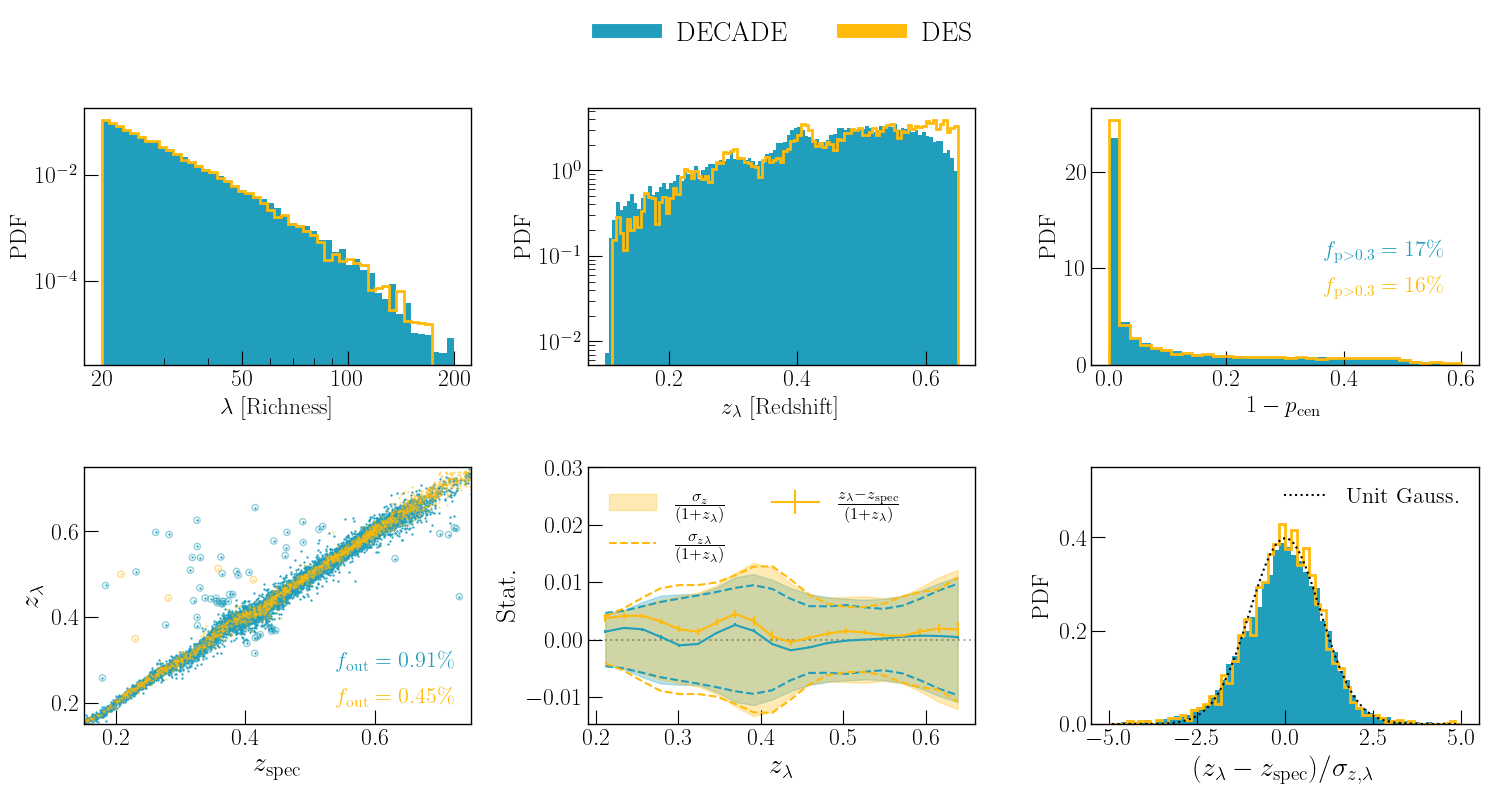

In [5]:
fig, ax = plt.subplots(2, 3, figsize = (18, 8))
plt.subplots_adjust(hspace = 0.4, wspace = 0.3)
aflat   = ax.flat
bins = np.geomspace(20, 200, 50)

##########################################
# FIRST PANEL
##########################################
clrs = aflat[0].hist(decade['lambda'], bins = bins, density = True, log = True, color = 'C1', label = 'DECADE')
aflat[0].hist(des['lambda'], bins = bins, histtype = 'step', color = 'C2', density = True, log = True, label = 'DES', lw = 2);
aflat[0].set_xlabel(r'$\lambda$ [Richness]', size = 17)
aflat[0].set_ylabel('PDF', size = 17)
aflat[0].set_xscale('log')

aflat[0].set_xticks([20, 50, 100, 200])
aflat[0].set_xticklabels([20, 50, 100, 200])


##########################################
# SECOND PANEL
##########################################

clrs = aflat[1].hist(decade['z_lambda'], bins = np.linspace(0.1, 0.65, 100), density = True, color = 'C1', log = True, label = 'DECADE')
aflat[1].hist(des['z_lambda'], bins = clrs[1], histtype = 'step', color = 'C2', density = True, log = True, label = 'DES', lw = 2);
aflat[1].set_xlabel(r'$z_\lambda$ [Redshift]', size = 17)
aflat[1].set_ylabel('PDF', size = 17)

##########################################
# THIRD PANEL
##########################################

p_decade = np.sum(decade['p_cen'][:, 1:], axis = 1)
p_des    = np.sum(des['p_cen'][:, 1:], axis = 1)
clrs = aflat[2].hist(p_decade, bins = np.linspace(0, 0.6, 35), color = 'C1', density = True, log = False, label = 'DECADE')
aflat[2].hist(p_des, bins = clrs[1], histtype = 'step', color = 'C2', density = True, log = False, label = 'DES', lw = 2);
aflat[2].set_xlabel(r'$1 - p_{\rm cen}$', size = 17)
aflat[2].set_ylabel('PDF', size = 17)

f_decade = np.average(p_decade > 0.3)
f_des    = np.average(p_des    > 0.3)

aflat[2].text(0.6, 0.42, fr'$f_{{\rm p > 0.3}} = {int(f_decade * 100)}\%$', size = 16, color = 'C1', transform = aflat[2].transAxes)
aflat[2].text(0.6, 0.28, fr'$f_{{\rm p > 0.3}} = {int(f_des    * 100)}\%$', size = 16, color = 'C2', transform = aflat[2].transAxes)


##########################################
# FOURTH PANEL
##########################################


msk = decade['cg_spec_z'] > -1
aflat[3].scatter(decade['cg_spec_z'][msk], decade['z_lambda'][msk], s = 0.4, color = 'C1', rasterized = True)
out  = (np.abs(decade['z_lambda'] - decade['cg_spec_z']) / decade['cg_spec_z'])[msk] > 0.15
eta  = np.average(out)
print(out.size, out.sum(), eta)
aflat[3].scatter(decade['cg_spec_z'][msk][out], decade['z_lambda'][msk][out], s = 20, alpha = 0.5, color = 'C1', facecolor = 'none', rasterized = True)
aflat[3].text(0.65, 0.22, fr'$f_{{\rm out}} = {eta * 100:0.2f}\%$', size = 16, color = 'C1', transform = aflat[3].transAxes)

msk = des['cg_spec_z'] > -1
aflat[3].scatter(des['cg_spec_z'][msk], des['z_lambda'][msk], s = 0.4, color = 'C2', alpha = 0.5, rasterized = True);
out  = (np.abs(des['z_lambda'] - des['cg_spec_z']) / des['cg_spec_z'])[msk] > 0.15
eta  = np.average(out)
print(out.size, out.sum(), eta)
aflat[3].scatter(des['cg_spec_z'][msk][out], des['z_lambda'][msk][out], s = 20, alpha = 0.5, color = 'C2', facecolor = 'none', rasterized = True);
aflat[3].text(0.65, 0.08, fr'$f_{{\rm out}} = {eta * 100:0.2f}\%$', size = 16, color = 'C2', transform = aflat[3].transAxes)

aflat[3].set_xlabel(r'$z_{\rm spec}$', size = 20)
aflat[3].set_ylabel(r'$z_{\lambda}$', size = 20)
aflat[3].set_ylim(0.15, 0.75)
aflat[3].set_xlim(0.15, 0.75)

##########################################
# FIFTH PANEL
##########################################

zbs = np.linspace(0.2, 0.65, 20 + 1)
zcn = (zbs[1:] + zbs[:-1])/2

msk = decade['cg_spec_z'] > -1
msk = msk & (np.abs(decade['z_lambda'] - decade['cg_spec_z']) / decade['cg_spec_z'] < 0.15)
z   = decade['z_lambda'][msk]
dz  = (decade['z_lambda'][msk] - decade['cg_spec_z'][msk]) / (1 + decade['z_lambda'][msk])
sz  = decade['z_lambda_e'][msk] / (1 + decade['z_lambda'][msk])

ind = [np.random.choice(len(z), len(z)) for _ in range(100)]
med = [stats.binned_statistic(z[m], dz[m], statistic = 'median', bins = zbs)[0] for m in ind]
avg = [stats.binned_statistic(z[m], dz[m], statistic = 'mean',   bins = zbs)[0] for m in ind]
std = [stats.binned_statistic(z[m], dz[m], statistic = 'std',    bins = zbs)[0] for m in ind]
err = [stats.binned_statistic(z[m], sz[m], statistic = 'median', bins = zbs)[0] for m in ind]

std = gaussian_filter1d(np.median(std, axis = 0), sigma = 1)
med = [gaussian_filter1d(m, sigma = 1) for m in med]
aflat[4].errorbar(zcn, np.median(med, axis = 0), yerr = np.std(med, axis = 0), color = 'C1')
aflat[4].fill_between(zcn, -std, std, color = 'C1', alpha = 0.3)
aflat[4].plot(zcn, np.median(err, axis = 0), color = 'C1', ls = '--')
aflat[4].plot(zcn, -np.median(err, axis = 0), color = 'C1', ls = '--')
# aflat[4].errorbar(zcn + 0.05, np.median(avg, axis = 0), yerr = np.std(avg, axis = 0), color = 'C0')


######## SWITCH TO DES ############

msk = des['cg_spec_z'] > -1
msk = msk & (np.abs(des['z_lambda'] - des['cg_spec_z']) / des['cg_spec_z'] < 0.15)
z   = des['z_lambda'][msk]
dz  = des['z_lambda'][msk] - des['cg_spec_z'][msk]
sz  = des['z_lambda_e'][msk]

ind = [np.random.choice(len(z), len(z)) for _ in range(100)]
med = [stats.binned_statistic(z[m], dz[m], statistic = 'median', bins = zbs)[0] for m in ind]
avg = [stats.binned_statistic(z[m], dz[m], statistic = 'mean',   bins = zbs)[0] for m in ind]
std = [stats.binned_statistic(z[m], dz[m], statistic = 'std',    bins = zbs)[0] for m in ind]
err = [stats.binned_statistic(z[m], sz[m], statistic = 'median', bins = zbs)[0] for m in ind]

std = gaussian_filter1d(np.median(std, axis = 0), sigma = 1)
med = [gaussian_filter1d(m, sigma = 1) for m in med]
aflat[4].errorbar(zcn, np.median(med, axis = 0), yerr = np.std(med, axis = 0), color = 'C2', label = r'$\frac{z_\lambda - z_{\rm spec}}{(1 + z_\lambda)}$')
aflat[4].fill_between(zcn, -std, std, color = 'C2', alpha = 0.3, label = r'$\frac{\sigma_{z}}{(1 + z_\lambda)}$')
aflat[4].plot(zcn, np.median(err, axis = 0), color = 'C2', ls = '--', label = r'$\frac{\sigma_{z\lambda}}{(1 + z_\lambda)}$')
aflat[4].plot(zcn, -np.median(err, axis = 0), color = 'C2', ls = '--')
# aflat[4].errorbar(zcn + 0.05, np.median(avg, axis = 0), yerr = np.std(avg, axis = 0), color = 'C2')

aflat[4].axhline(0, color = 'k', ls = ':', alpha = 0.3)
aflat[4].set_xlabel(r'$z_{\lambda}$', size = 20)
aflat[4].set_ylabel(r'Stat.', size = 20)
aflat[4].legend(loc = 'upper left', ncol = 2)
aflat[4].set_ylim(None, 0.03)

##########################################
# SIXTH PANEL
##########################################

msk = decade['cg_spec_z'] > -1
sig = (decade['z_lambda'] - decade['cg_spec_z'])/decade['z_lambda_e']
clrs = aflat[5].hist(sig[msk] - np.mean(sig[msk]), bins = 60, density = True, range = (-5, 5), color = 'C1')

msk = des['cg_spec_z'] > -1
sig = (des['z_lambda'] - des['cg_spec_z'])/des['z_lambda_e']
aflat[5].hist(sig[msk] - np.mean(sig[msk]), bins = clrs[1], density = True, color = 'C2', histtype = 'step', lw = 2)
aflat[5].set_xlabel(r'$(z_{\rm \lambda} - z_{\rm spec}) / \sigma_{z, {\lambda}}$', size = 20)
aflat[5].set_ylabel(r'PDF', size = 17)

cen   = (clrs[1][1:] + clrs[1][:-1])/2
gauss = 1/np.sqrt(2 * np.pi) * np.exp(-np.power(cen, 2)/2)
aflat[5].plot(cen, gauss, color = 'k', ls = ':', label = 'Unit Gauss.')
aflat[5].legend(loc = 'upper right', fontsize = 16)
aflat[5].set_ylim(None, 0.55)
fig.legend(
    [plt.plot([], [], lw = 10, color = c)[0] for c in ['C1', 'C2']],
    ['DECADE', 'DES'],
    loc='upper center',
    ncol=2,
    frameon=False,
    fontsize=20,
    bbox_to_anchor=(0.515, 1.02),
)

plt.savefig('./CharacterizeCatalog.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()